<a href="https://colab.research.google.com/github/LucasBLR86/financial-data-science-portfolio/blob/main/FIIs_com__Machine__Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Segmentação de Fundos Imobiliários com Machine Learning

In [2]:
# PROJETO: Segmentação de Fundos Imobiliários com Machine Learning
# AUTOR: Lucas Bragança
# DATA: 28/04/2024

# OBJETIVO:
# Este projeto tem como objetivo analisar e segmentar Fundos Imobiliários (FIIs)
# utilizando indicadores financeiros e técnicas de Machine Learning,
# com foco em identificar padrões de risco, retorno e liquidez.

# ORIGEM DOS DADOS:
# Dados baseados em fontes públicas como Status Invest e Funds Explorer, estruturados manualmente para fins de análise.

# PERÍODO DOS DADOS:
# A base representa um recorte transversal (snapshot) do mercado, com indicadores recentes (aprox. final de 2025 / início de 2026).
# Algumas variáveis refletem janelas temporais específicas:
# - Dividend Yield: últimos 12 meses (LTM)
# - Variação: últimos 12 meses
# - Liquidez: média recente

# OBSERVAÇÃO:
# Este projeto não tem como objetivo prever preços, mas sim identificar padrões e perfis de ativos.

**ETL -  DE EXTRAÇÃO, TRATAMENTO E LIMPEZA DOS DADOS**

In [3]:
# ============================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [6]:
# CARREGAMENTO DA BASE DE DADOS


df = pd.read_csv('fiis_indicadores.csv')

# Visualização inicial
df.head()

,ticker,segmento,preco,dy,p_vp,liquidez_diaria,patrimonio_liquido,vacancia,variacao_12m
0,MXRF11,Papel,10.2,12.5,0.96,2500000,2500000000,0.0,5.8
1,KNCR11,Papel,102.5,9.2,1.02,1200000,3000000000,0.0,4.2
2,KNIP11,Papel,95.3,10.1,0.98,900000,2200000000,0.0,3.5
3,KNHY11,Papel,98.7,11.3,1.01,800000,1800000000,0.0,6.1
4,IRDM11,Papel,87.4,13.2,0.92,1500000,2000000000,0.0,7.4


In [7]:
# VERIFICAÇÃO DE DADOS FALTANTES

df.isnull().sum()

,0
ticker,0
segmento,0
preco,0
dy,0
p_vp,0
liquidez_diaria,0
patrimonio_liquido,0
vacancia,0
variacao_12m,0


**ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)**

In [12]:
#Overview da Base

df.head()
df.shape

#Tipos dos dados
df.info()

#Resultados da Análise Exploratória
#A base de dados é composta por 47 Fundos Imobiliários e 9 variáveis, abrangendo indicadores financeiros relevantes para análise.
#Observa-se que não há valores nulos, garantindo consistência e confiabilidade para as próximas etapas do projeto.
#Além disso, as variáveis numéricas estão corretamente tipadas, permitindo aplicação direta de técnicas estatísticas e de machine learning.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ticker              47 non-null     object 
 1   segmento            47 non-null     object 
 2   preco               47 non-null     float64
 3   dy                  47 non-null     float64
 4   p_vp                47 non-null     float64
 5   liquidez_diaria     47 non-null     int64  
 6   patrimonio_liquido  47 non-null     int64  
 7   vacancia            47 non-null     float64
 8   variacao_12m        47 non-null     float64
dtypes: float64(5), int64(2), object(2)
memory usage: 3.4+ KB


**ESTATISTICA DESCRITIVA**




In [13]:
df.describe()

,preco,dy,p_vp,liquidez_diaria,patrimonio_liquido,vacancia,variacao_12m
count,47.000000,47.000000,47.000000,4.700000e+01,4.700000e+01,47.000000,47.000000
mean,93.010638,9.897872,0.943191,1.008511e+06,2.280851e+09,2.906383,3.414894
std,31.856255,1.790979,0.061081,6.478492e+05,1.341744e+09,4.263363,3.593532
min,9.800000,7.500000,0.780000,3.000000e+05,9.000000e+08,0.000000,-8.500000
25%,81.250000,8.550000,0.910000,6.000000e+05,1.400000e+09,0.000000,3.050000
50%,89.700000,9.300000,0.950000,8.000000e+05,1.800000e+09,2.000000,4.200000
75%,100.600000,10.750000,0.980000,1.200000e+06,2.500000e+09,3.750000,5.750000
max,215.000000,15.100000,1.050000,3.000000e+06,7.000000e+09,18.000000,7.400000


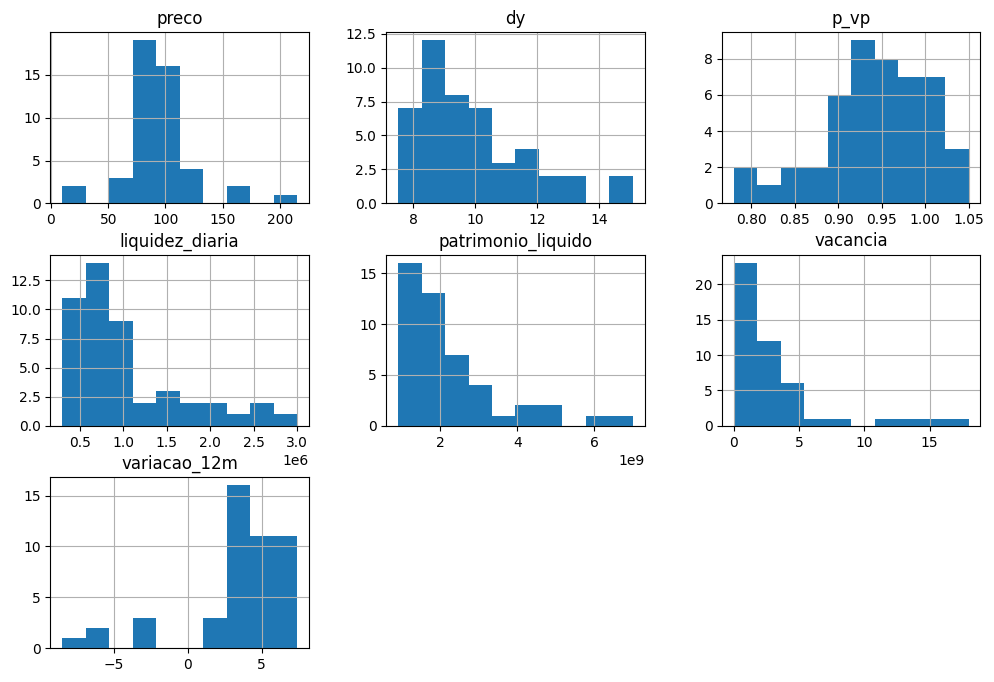

In [14]:
#Distribuição das variáveis
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()

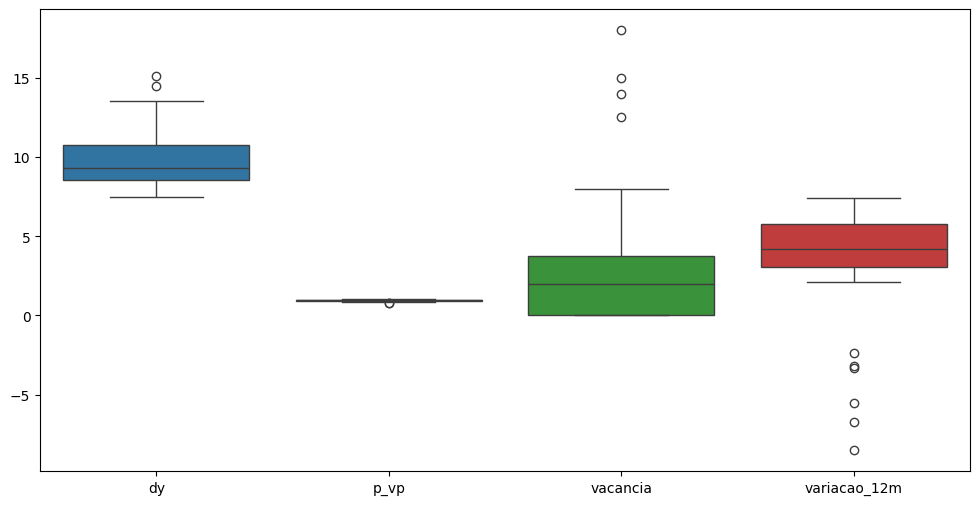

In [15]:
#Boxplot (detectar outliers)
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[['dy','p_vp','vacancia','variacao_12m']])
plt.show()

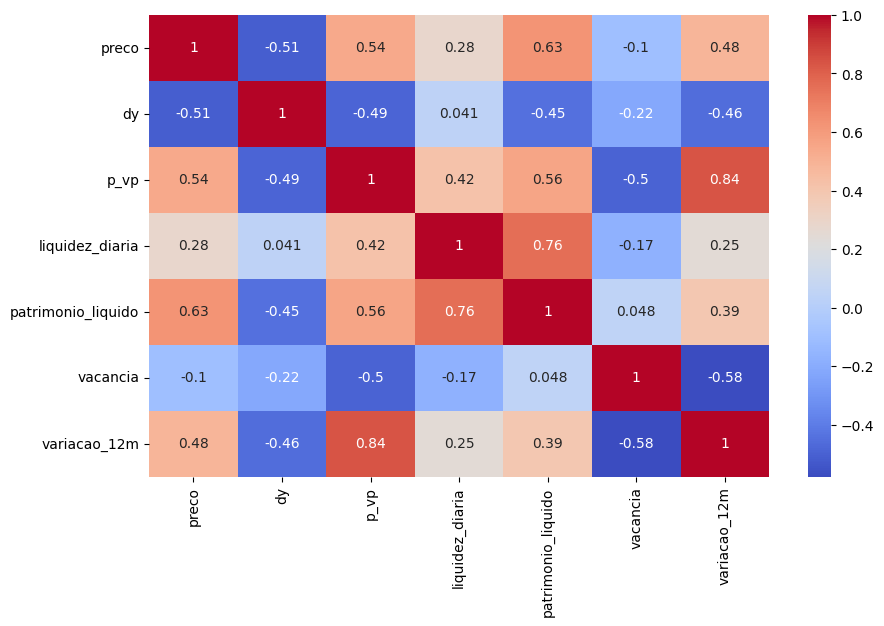

In [17]:
#Correlação entre variáveis
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

**RESUMO EXECUTIVO E PRINCIPAIS INSIGHTS DA ANÁLISE EXPLORATÓRIA DOS DADOS E ESTATISTICA DESCRITIVA**

Resumo executivo

A análise evidencia que o mercado de FIIs não é homogêneo e apresenta diferentes perfis de ativos, variando entre fundos mais defensivos, voltados à estabilidade, e fundos mais arriscados, com maior potencial de retorno. Observa-se que indicadores como P/VP, vacância e dividend yield refletem diretamente a percepção de risco e qualidade dos ativos, influenciando seu desempenho no mercado.

Nesse contexto, decisões baseadas em um único indicador podem ser limitadas, reforçando a importância de uma análise mais integrada para construção de carteira e alocação eficiente.



---



Insights

1. Relação clara entre valuation e retorno
Existe uma forte correlação positiva entre P/VP e variação 12m (0.84)
FIIs mais “caros” (P/VP maior) tendem a ter melhor desempenho recente

Leitura de mercado:
O mercado está precificando qualidade, não apenas desconto.






2. Alto Dividend Yield pode indicar maior risco
DY tem correlação negativa com:
P/VP (-0.49)
Variação (-0.46)

FIIs com DY mais alto tendem a:
Ser mais descontados
Ter pior performance recente



3. Vacância impacta diretamente a performance
Correlação negativa relevante com variação (-0.58)

Quanto maior a vacância:
Pior tende a ser o desempenho do fundo

Leitura:
Vacância é um dos principais drivers de risco em FIIs de tijolo.



4. Liquidez e tamanho andam juntos
Liquidez vs patrimônio: 0.76 (alta correlação)

FIIs maiores tendem a:
Ter maior liquidez
Ser mais negociados

Leitura:
Isso reforça o comportamento de mercado institucional.



5. Distribuições mostram assimetria e outliers

Pelos histogramas e boxplots:

DY com cauda à direita → presença de fundos com rendimento muito alto
Vacância com outliers fortes (até ~18%)
Variação com valores negativos relevantes

Isso indica:

Mercado heterogêneo
Presença de ativos com risco elevado
Base ideal para clusterização



6. Mercado não é homogêneo Os dados mostram claramente:

FIIs com perfil defensivo
FIIs com perfil de risco elevado
FIIs mais equilibrados



**ANÁLISES DE MERCADO E PERFIS DE FIIs**

In [20]:
#Top 10 DY
df.sort_values(by='dy', ascending=False).head(10)

,ticker,segmento,preco,dy,p_vp,liquidez_diaria,patrimonio_liquido,vacancia,variacao_12m
6,DEVA11,Papel,82.2,15.1,0.88,1800000,1600000000,0.0,-5.5
5,HCTR11,Papel,75.1,14.5,0.85,2000000,1700000000,0.0,-3.2
9,JSCR11,Papel,88.3,13.5,0.91,600000,1300000000,0.0,3.1
4,IRDM11,Papel,87.4,13.2,0.92,1500000,2000000000,0.0,7.4
0,MXRF11,Papel,10.2,12.5,0.96,2500000,2500000000,0.0,5.8
46,BTCR11,Papel,88.9,12.1,0.95,700000,1500000000,0.0,4.1
7,VGIR11,Papel,9.8,12.0,0.95,1000000,1400000000,0.0,2.3
8,RECR11,Papel,96.1,11.7,0.97,850000,1900000000,0.0,4.9
44,BARI11,Papel,95.7,11.5,0.94,500000,1400000000,0.0,3.6
3,KNHY11,Papel,98.7,11.3,1.01,800000,1800000000,0.0,6.1


In [21]:
#Top 10 mais descontados (P/VP baixo)
df.sort_values(by='p_vp').head(10)

,ticker,segmento,preco,dy,p_vp,liquidez_diaria,patrimonio_liquido,vacancia,variacao_12m
14,BRCR11,Lajes,60.8,11.0,0.78,900000,3000000000,18.0,-8.5
13,RECT11,Lajes,65.2,10.3,0.80,400000,1200000000,15.0,-6.7
15,RBRP11,Lajes,58.4,10.7,0.82,350000,1000000000,14.0,-3.3
5,HCTR11,Papel,75.1,14.5,0.85,2000000,1700000000,0.0,-3.2
11,VINO11,Lajes,72.5,9.1,0.85,650000,1800000000,12.5,-2.4
6,DEVA11,Papel,82.2,15.1,0.88,1800000,1600000000,0.0,-5.5
41,URPR11,Urbano,75.6,10.8,0.88,400000,900000000,1.0,3.2
35,MGFF11,FOF,75.9,10.0,0.89,300000,1000000000,0.0,2.5
32,BCFF11,FOF,78.6,9.8,0.90,600000,1500000000,0.0,2.9
39,RBFF11,FOF,80.4,9.9,0.90,500000,1200000000,0.0,2.7


In [22]:
#Maior liquidez
df.sort_values(by='liquidez_diaria', ascending=False).head(10)

,ticker,segmento,preco,dy,p_vp,liquidez_diaria,patrimonio_liquido,vacancia,variacao_12m
22,HGLG11,Logistica,165.0,8.2,1.05,3000000,5000000000,2.1,7.3
21,XPLG11,Logistica,110.0,8.0,1.02,2500000,6000000000,2.0,6.5
0,MXRF11,Papel,10.2,12.5,0.96,2500000,2500000000,0.0,5.8
16,XPML11,Shopping,115.0,8.8,0.98,2200000,4500000000,3.5,6.0
29,KNRI11,Hibrido,155.0,7.5,1.02,2000000,7000000000,3.0,6.8
5,HCTR11,Papel,75.1,14.5,0.85,2000000,1700000000,0.0,-3.2
6,DEVA11,Papel,82.2,15.1,0.88,1800000,1600000000,0.0,-5.5
17,VISC11,Shopping,105.4,8.5,0.97,1800000,4000000000,4.2,5.7
4,IRDM11,Papel,87.4,13.2,0.92,1500000,2000000000,0.0,7.4
18,HGBS11,Shopping,215.0,8.2,1.01,1500000,5000000000,3.0,7.1


In [23]:
#Distribuição por segmento
df['segmento'].value_counts()

,count
segmento,
Papel,12
FOF,9
Logistica,8
Lajes,6
Shopping,5
Hibrido,3
Saude,1
Urbano,1
Varejo,1


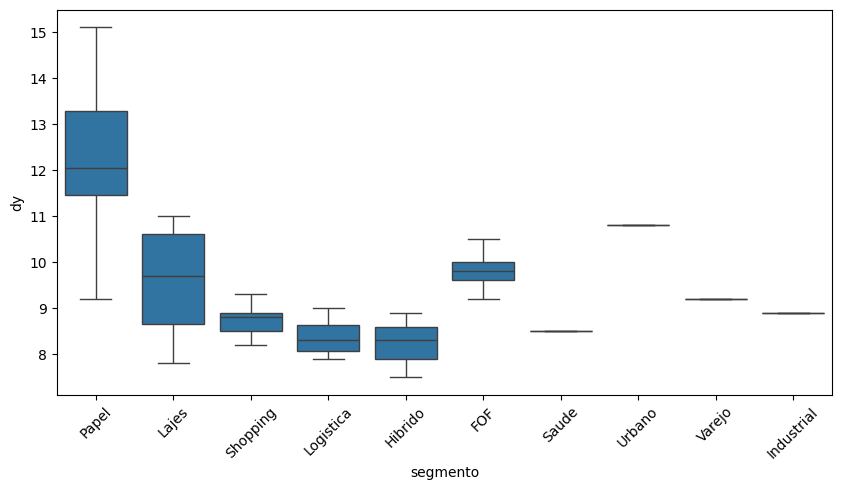

In [24]:
#DY por segmento
plt.figure(figsize=(10,5))
sns.boxplot(x='segmento', y='dy', data=df)
plt.xticks(rotation=45)
plt.show()

**RESUMO EXECUTIVO E PRINCIPAIS INSIGHTS DA ANÁLISE DE MERCADO E PERFIS DAS FIIs**

Resumo executivo

A análise dos rankings e da distribuição por segmento evidencia um mercado de FIIs bem segmentado, onde fundos de papel se destacam em retorno, enquanto ativos de tijolo, como logística e shoppings, apresentam maior estabilidade e liquidez. Observa-se que fundos mais descontados estão frequentemente associados a maiores riscos operacionais, como vacância elevada e desempenho negativo recente. Nesse contexto, a leitura isolada de indicadores pode induzir a erros, reforçando a importância de uma análise integrada para tomada de decisão e construção de portfólio mais eficiente.



---



---


1. Fundos de papel dominam o ranking de Dividend Yield
Top DY praticamente todo composto por FIIs de papel (CRI)
DY chegando a 15%+

Leitura de mercado: Fundos de papel estão entregando maior renda no curto prazo, mas isso pode refletir:

maior risco de crédito
maior sensibilidade a juros

Insight:

Alto dividendo pode ser mais reflexo de risco do que de oportunidade.

2. FIIs mais descontados estão ligados a problemas operacionais
Lajes corporativas dominam os menores P/VP
Vacância extremamente alta (até 18%)
Performance negativa relevante

Leitura de mercado: O desconto não é “barato” — é precificação de risco real.

Insight:

Mercado está penalizando ativos com dificuldade de ocupação e baixa previsibilidade de receita.

3. Liquidez concentra nos ativos de maior qualidade e escala
Logística e grandes fundos lideram liquidez
FIIs com maior patrimônio aparecem no topo

Leitura: Preferência do mercado por ativos mais seguros
maior presença de investidores institucionais

Insight:

Liquidez funciona como proxy de qualidade percebida no mercado.

4. Segmentação clara entre renda e estabilidade

Pelo boxplot:

Papel → maior DY, maior dispersão
Logística e shoppings → menor DY, mais estáveis
FOFs → intermediários

Leitura de portfólio:

Papel → renda
Logística → estabilidade
FOF → diversificação

Insight:

Cada segmento cumpre um papel diferente na construção de carteira.

5. Mercado de FIIs não é homogêneo (isso valida seu projeto)

Distribuição:

Papel (12) domina
Boa presença de FOF e logística
Nichos com menor representatividade



Insight:

Existem múltiplos perfis de ativos convivendo no mercado





**NORMALIZAÇÃO DOS DADOS PARA APLICAÇÃO DAS TÉCNICAS DE UNSUOERVISED MACHINE LEARNING**

In [26]:
#Selecionar variáveis numéricas
features = ['dy', 'p_vp', 'liquidez_diaria', 'patrimonio_liquido', 'vacancia', 'variacao_12m']

X = df[features]

#Aplicar StandardScaler - isso coloca todas as variáveis na mesma escala
#média = 0 desvio padrão = 1

#Motivo: Técnicas baseadas em distância, como K-Means e PCA, são sensíveis
#à escala das variáveis. Sem padronização, variáveis com maior magnitude
#dominariam a análise.


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**PCA (Análise de Componentes Principais) - Reduzir a dimensionalidade dos dados e identificar os principais fatores que explicam o comportamento dos FIIs.**

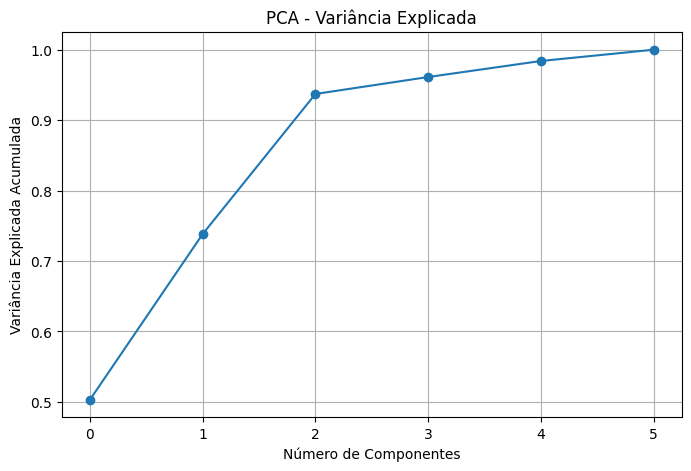

In [29]:
# PCA

from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

# Variância explicada por componente
explained_variance = pca.explained_variance_ratio_

#Gráfico da variância acumulada
explained_variance
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('PCA - Variância Explicada')
plt.grid()
plt.show()

In [30]:
#Reduzir para 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Criar DataFrame para análise
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['ticker'] = df['ticker']

#Entender o que cada componente representa
loadings = pd.DataFrame(pca.components_, columns=features, index=['PC1', 'PC2'])
loadings

,dy,p_vp,liquidez_diaria,patrimonio_liquido,vacancia,variacao_12m
PC1,-0.302310,0.534467,0.350615,0.435675,-0.25988,0.492618
PC2,-0.393173,-0.128842,0.203464,0.454037,0.71218,-0.272152


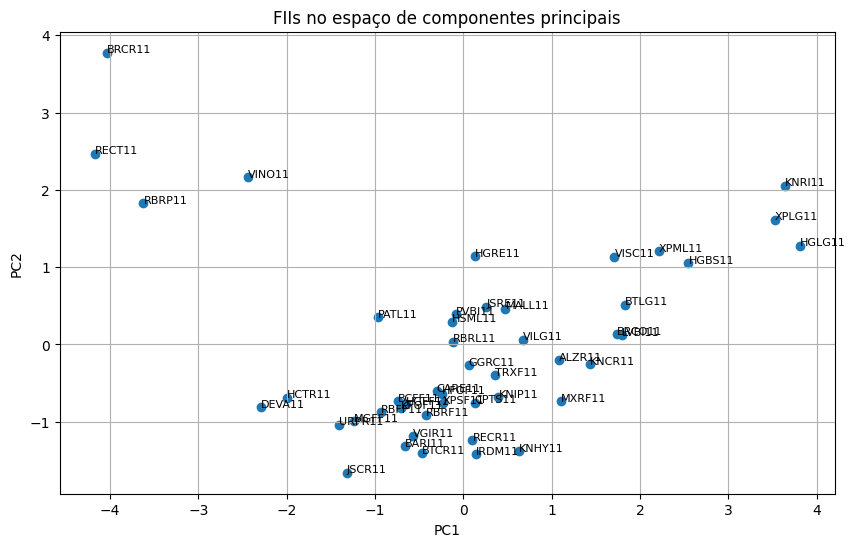

In [31]:
#Visualização (antes do K-Means)
plt.figure(figsize=(10,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'])

for i in range(df_pca.shape[0]):
    plt.text(df_pca['PC1'][i], df_pca['PC2'][i], df_pca['ticker'][i], fontsize=8)

plt.title('FIIs no espaço de componentes principais')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid()
plt.show()

**RESUMO EXECUTIVO E PRONCIPAIS INSIGHTS DO PCA**

A aplicação do PCA evidencia que o comportamento dos FIIs pode ser explicado majoritariamente por dois fatores principais, que capturam cerca de 74% da variabilidade dos dados. Esses fatores refletem, de forma agregada, dimensões relacionadas a retorno, valuation, liquidez e qualidade operacional dos ativos. A visualização no espaço de componentes principais mostra uma clara separação entre diferentes perfis de FIIs, indicando que o mercado não é homogêneo e que os ativos se organizam em grupos com características distintas. Esse resultado reforça a viabilidade de segmentação dos FIIs como ferramenta de apoio à alocação e construção de portfólio.


---
1. O mercado de FIIs é explicado por poucos fatores estruturais
2 componentes explicam ~74% dos dados
Forte compressão da informação

Leitura de mercado: O comportamento dos FIIs não é aleatório — ele é guiado por poucos drivers claros, como:

risco vs retorno
qualidade vs fragilidade operacional

2. Interpretação econômica dos componentes (PONTO MAIS FORTE)
🔹 PC1 → eixo de “qualidade vs risco-retorno”

Com base nos loadings:

P/VP, patrimônio, liquidez, variação
DY e vacância

Interpretação:

FIIs à direita (PC1 positivo) → maior qualidade, liquidez e valorização
FIIs à esquerda → maior risco, maior DY e possível fragilidade

PC2 → eixo de “risco operacional”
Forte peso de vacância (+0.71)
Influência negativa da variação

Interpretação:

FIIs mais acima → maior risco operacional (vacância elevada)
FIIs mais abaixo → maior estabilidade operacional

3. O gráfico revela clusters naturais (mesmo sem K-Means)

Lado esquerdo (PC1 negativo)
FIIs com alto DY
Mais descontados
Performance pior
Ex: DEVA11, HCTR11, BRCR11

Perfil:
FIIs mais arriscados / oportunísticos

Lado direito (PC1 positivo)
FIIs mais líquidos
Melhor performance
P/VP mais alto

Perfil:
FIIs mais “premium” / institucionais

Parte superior (PC2 alto)
FIIs com maior vacância
Problemas operacionais

Perfil:
Ativos com risco estrutural

Região central
FIIs equilibrados

Perfil:
Carteira balanceada / diversificada

4. Validação do que você viu no EDA

O PCA confirmou:

 DY alto ≠ qualidade
Vacância impacta fortemente
Liquidez e patrimônio andam juntos
Mercado separa ativos por risco



5. Insight  

O mercado de FIIs apresenta uma clara separação entre ativos orientados a renda, com maior risco, e ativos de maior qualidade e liquidez, indicando que retorno elevado, muitas vezes, é acompanhado de maior exposição a risco operacional e de crédito.

A análise sugere que a construção de carteira eficiente deve equilibrar ativos posicionados em diferentes regiões do espaço de componentes, combinando fundos de maior estabilidade com ativos de maior potencial de retorno.







**CLUSTERIZAÇÃO DE FIIs E IDENTIFICAÇÃO DE PERFIL DE INVESTIMENTO**

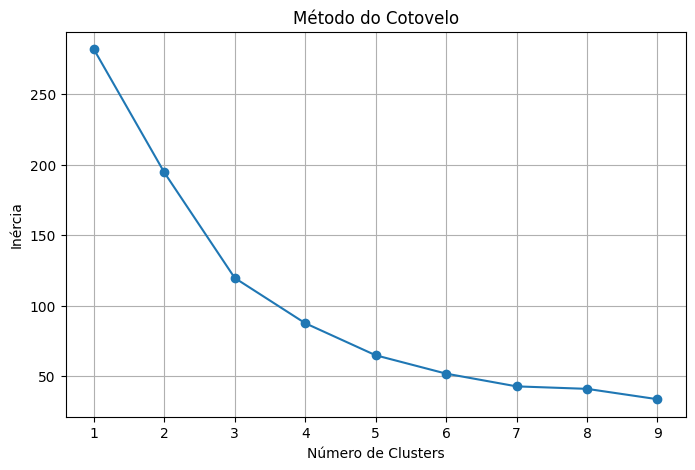

In [32]:
# Definição do número de clusters (Método do cotovelo)


from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.grid()
plt.show()

In [35]:
#Rodar o K-Means com k = 4
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters
df_pca['cluster'] = clusters

df.groupby('cluster')[[
    'dy',
    'p_vp',
    'liquidez_diaria',
    'patrimonio_liquido',
    'vacancia',
    'variacao_12m'
]].mean()

,dy,p_vp,liquidez_diaria,patrimonio_liquido,vacancia,variacao_12m
cluster,,,,,,
0,8.663636,1.010000,1.845455e+06,4.209091e+09,2.227273,6.072727
1,9.973333,0.941333,7.000000e+05,1.686667e+09,1.753333,4.110000
2,14.800000,0.865000,1.900000e+06,1.650000e+09,0.000000,-4.350000
3,10.275000,0.812500,5.750000e+05,1.750000e+09,14.875000,-5.225000


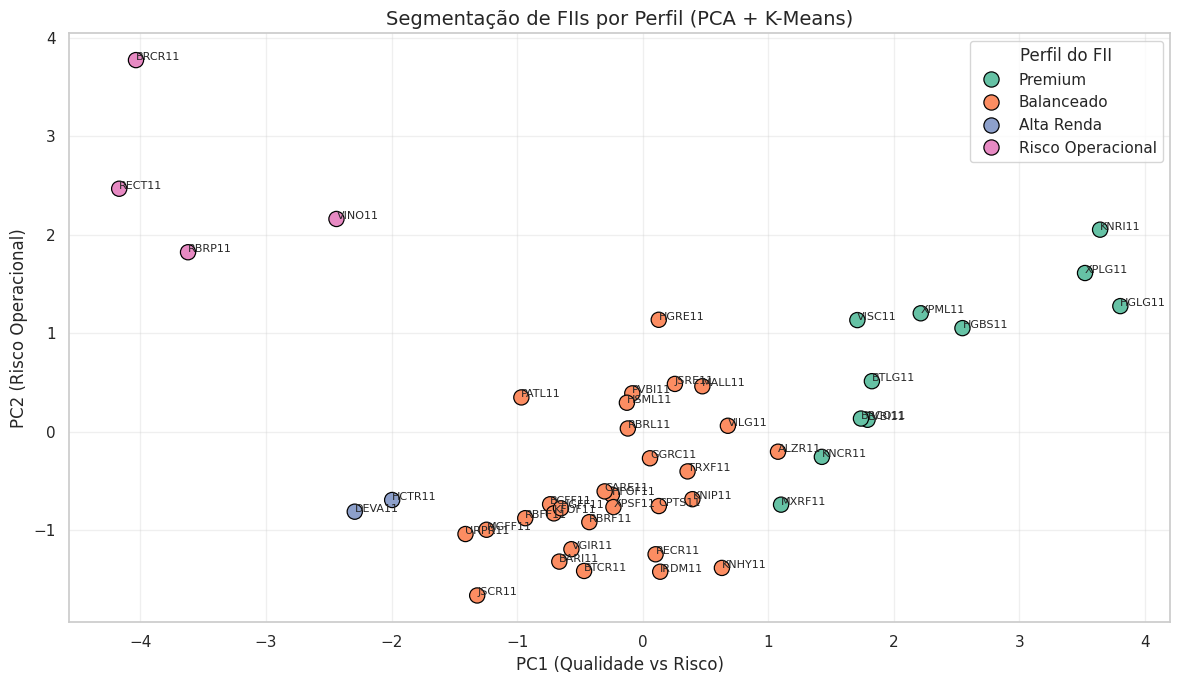

In [40]:
#Análise dos Clusters

cluster_names = {
    0: 'Premium',
    1: 'Balanceado',
    2: 'Alta Renda',
    3: 'Risco Operacional'
}

df_pca['cluster_nome'] = df_pca['cluster'].map(cluster_names)


import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='cluster_nome',
    hue_order=['Premium', 'Balanceado', 'Alta Renda', 'Risco Operacional'],
    palette='Set2',
    s=120,
    edgecolor='black'
)

# Adicionar labels (tickers)
for i in range(df_pca.shape[0]):
    plt.text(
        df_pca['PC1'][i],
        df_pca['PC2'][i],
        df_pca['ticker'][i],
        fontsize=8
    )

plt.title('Segmentação de FIIs por Perfil (PCA + K-Means)', fontsize=14)
plt.xlabel('PC1 (Qualidade vs Risco)')
plt.ylabel('PC2 (Risco Operacional)')
plt.legend(title='Perfil do FII')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**RELATÓRIO FINAL: SÍNTESE DOS RESULTADOS E INTERPRETAÇÃO DOS PERFIS DE FIIs**

A análise permitiu segmentar os FIIs em perfis distintos, evidenciando que o mercado se organiza de forma clara entre ativos de maior qualidade, fundos equilibrados, ativos voltados à geração de renda e FIIs com fragilidades operacionais. Essa segmentação mostra que o comportamento dos fundos não é aleatório, mas sim guiado por características estruturais que refletem diferentes níveis de risco, retorno e liquidez.

Observa-se que fatores como liquidez, vacância e valuation exercem papel central na dinâmica de preços e desempenho dos ativos. Fundos com maior liquidez e qualidade tendem a apresentar maior estabilidade e valorização ao longo do tempo, enquanto ativos com maior vacância ou desconto elevado frequentemente incorporam maior incerteza quanto à geração de receita e à sustentabilidade dos rendimentos.

Um ponto relevante identificado na análise é que FIIs com maior dividend yield estão concentrados, em grande parte, nos clusters de maior risco ou menor qualidade percebida. Isso sugere que retornos mais elevados, muitas vezes, representam um prêmio de risco, e não necessariamente uma oportunidade clara de investimento, reforçando a importância de avaliar o contexto do ativo e não apenas o indicador isolado.

É importante destacar que esta análise não tem como objetivo recomendar ou desaconselhar investimentos específicos, tampouco emitir juízo de valor sobre os ativos. Trata-se de uma leitura de cenário baseada em dados, com o propósito de demonstrar como ferramentas de Machine Learning podem ser utilizadas para identificar padrões e apoiar decisões mais estruturadas no mercado financeiro.

Como implicação prática, os resultados indicam que decisões baseadas exclusivamente em métricas individuais, como o dividend yield, podem levar a distorções na construção de carteira. Nesse sentido, a abordagem multifatorial adotada no projeto se mostra mais adequada, permitindo uma visão integrada dos ativos e contribuindo para a construção de portfólios mais equilibrados, que combinem qualidade, estabilidade e, de forma tática, exposição a maiores retornos.